# Лабораторная работа № 2
## Методы машинного обучения и обработки естественного языка для анализа юридических текстов

**Охватываемый материал:** Лекции 3, 4, 5

---

### Цель работы

Целью настоящей лабораторной работы является формирование практических компетенций в области применения методов машинного обучения и обработки естественного языка (NLP) к задачам автоматизированной обработки юридических текстов. В ходе выполнения работы студент освоит полный конвейер обработки текстовых данных — от формирования корпуса и предобработки до построения классификатора, оценки его качества и проведения специализированного анализа согласно индивидуальному варианту.

### Задачи работы

Выполнение лабораторной работы предполагает решение следующих задач: (1) формирование и разведочный анализ тематического корпуса судебных документов; (2) реализация конвейера предобработки текстов с лемматизацией и фильтрацией стоп-слов; (3) извлечение числового представления документов методом, предусмотренным вариантом; (4) обучение, настройка и сравнительная оценка алгоритмов классификации; (5) выполнение специализированного аналитического задания (тематическое моделирование, обнаружение аномалий, семантический поиск, визуализация, подбор гиперпараметров или нейросетевая классификация) согласно варианту.

### Необходимое программное обеспечение

Для выполнения работы необходима среда выполнения Python 3.9 или новее с установленными пакетами, перечисленными в ячейке инициализации. Все используемые инструменты относятся к свободно распространяемому программному обеспечению и доступны через менеджер пакетов pip.

---


## 1. Краткая теоретическая справка

### 1.1. Конвейер обработки текстовых данных

Анализ юридических текстов методами машинного обучения реализуется в форме последовательного конвейера преобразований. Каждый документ $d_i$ из коллекции $\mathcal{D} = \{d_1, \ldots, d_N\}$ проходит через функцию предобработки $g: D \to D'$, функцию извлечения признаков $\phi: D' \to \mathbb{R}^m$ и классификатор $f_\theta: \mathbb{R}^m \to \mathcal{Y}$. Итоговый результат для документа $d_i$ есть $\hat{y}_i = f_\theta(\phi(g(d_i)))$.

Предобработка юридических текстов включает очистку от артефактов форматирования, токенизацию, удаление стоп-слов и лемматизацию. Лемматизация — приведение словоформ к базовой форме — принципиально важна для высокофлективного русского языка: формы «судебном», «судебных», «судебного» объединяются в единую лемму «судебный», что сокращает размерность словаря и повышает обобщающую способность модели.

### 1.2. Методы векторного представления текста

**Модель «мешок слов» (Bag of Words, BoW)** представляет документ вектором абсолютных частот термов. Для документа $d$ вектор $\phi_{\text{BoW}}(d) \in \mathbb{Z}^{|V|}$, где $|V|$ — размер словаря. Метод игнорирует порядок слов, однако остаётся эффективным для многих задач классификации.

**TF-IDF** (Term Frequency–Inverse Document Frequency) взвешивает вклад термина $t$ в документе $d$ по формуле:
$$\text{tfidf}(t, d) = \text{tf}(t, d) \cdot \log\frac{|\mathcal{D}|}{1 + |\{d' : t \in d'\}|}$$
где $\text{tf}(t, d) = \frac{\text{count}(t, d)}{\sum_{t'} \text{count}(t', d)}$ — относительная частота термина. Высокий TF-IDF вес получают слова, характерные для данного документа, но редкие в коллекции в целом.

**Символьные $n$-граммы** (character $n$-grams) представляют документ векторами частот подстрок длины $n$. Данное представление устойчиво к опечаткам и позволяет улавливать морфологические закономерности, не зависящие от границ слов.

### 1.3. Алгоритмы классификации

**Логистическая регрессия** вычисляет вероятности классов через функцию softmax: $P(y=k \mid x) = \frac{\exp(w_k^\top x)}{\sum_j \exp(w_j^\top x)}$. Параметры оцениваются максимизацией правдоподобия с $L_2$-регуляризацией. Метод хорошо масштабируется на высокоразмерные разреженные пространства TF-IDF.

**Метод опорных векторов (LinearSVC)** минимизирует hinge-функцию потерь, ища гиперплоскость максимального зазора между классами. В задачах классификации текстов LinearSVC с линейным ядром нередко превосходит ядровые варианты за счёт достаточной линейной разделимости в высокоразмерных TF-IDF пространствах.

**Наивный байесовский классификатор (MultinomialNB)** применяет теорему Байеса: $P(y \mid x) \propto P(y) \prod_j P(x_j \mid y)$, предполагая условную независимость признаков. Несмотря на упрощённость предположения, метод показывает конкурентоспособные результаты на задачах классификации текстов.

**Случайный лес (Random Forest)** строит ансамбль из $B$ деревьев решений на бутстрап-выборках: $\hat{y} = \text{mode}\{T_1(x), \ldots, T_B(x)\}$. Декорреляция деревьев достигается случайным выбором подмножества признаков при каждом разбиении.

**Градиентный бустинг (Gradient Boosting)** аддитивно строит ансамбль слабых учеников: $F_m(x) = F_{m-1}(x) + \eta \cdot h_m(x)$, где $h_m$ — дерево, обученное на псевдоостатках $-\nabla_{F} \mathcal{L}$.

**Многослойный перцептрон (MLP)** реализует нелинейную классификацию через несколько полносвязных слоёв с нелинейными функциями активации. Каждый скрытый нейрон вычисляет $a = \sigma(w^\top x + b)$, где $\sigma$ — функция активации (ReLU, tanh).

### 1.4. Оценка качества

Точность (Precision), полнота (Recall) и $F_1$-мера для класса $k$ вычисляются через матрицу ошибок $C$:
$$\text{Precision}_k = \frac{C_{kk}}{\sum_i C_{ik}}, \quad \text{Recall}_k = \frac{C_{kk}}{\sum_j C_{kj}}, \quad F_1^{(k)} = \frac{2 \cdot \text{Prec}_k \cdot \text{Rec}_k}{\text{Prec}_k + \text{Rec}_k}$$

Для сравнения моделей применяется стратифицированная $k$-кратная кросс-валидация, обеспечивающая несмещённую оценку обобщающей способности.

### 1.5. Специализированные методы анализа

**Тематическое моделирование (LDA)** — метод обучения без учителя, представляющий каждый документ как смесь латентных тем. Модель максимизирует правдоподобие: $\log p(\mathcal{D}) = \sum_d \log p(d \mid \alpha, \beta)$, где $\alpha$ и $\beta$ — параметры распределений Дирихле.

**Обнаружение аномалий (Isolation Forest)** оценивает аномальность объекта $x$ через нормированную среднюю глубину изоляции: $s(x) = 2^{-E[h(x)]/c(n)}$, где $h(x)$ — число разбиений до изоляции.

**Семантический поиск** основан на косинусном сходстве между TF-IDF векторами запроса $q$ и документов:
$$\text{sim}(q, d) = \frac{q^\top d}{\|q\| \cdot \|d\|}$$

**Метод t-SNE** снижает размерность до 2D, минимизируя $KL(P \| Q)$ между попарными сходствами в исходном и целевом пространствах, позволяя визуализировать кластерную структуру документов.

---


## 2. Подготовка рабочей среды

In [1]:
# Установка необходимых библиотек
# Выполните эту ячейку перед началом работы

# !pip install scikit-learn numpy pandas matplotlib seaborn
# !pip install pymorphy3 pymorphy3-dicts-ru nltk
# !pip install gensim wordcloud

import warnings
warnings.filterwarnings('ignore')

import re
import random
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from collections import Counter

# scikit-learn
from sklearn.feature_extraction.text import (
    CountVectorizer, TfidfVectorizer
)
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB, ComplementNB
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier, IsolationForest
)
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import (
    train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
)
from sklearn.metrics import (
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, f1_score, accuracy_score
)
from sklearn.pipeline import Pipeline
from sklearn.decomposition import TruncatedSVD, LatentDirichletAllocation
from sklearn.preprocessing import normalize
from sklearn.manifold import TSNE

# Морфологический анализ
import pymorphy3
import nltk

# nltk.download('punkt', quiet=True)
# nltk.download('stopwords', quiet=True)

# Фиксация случайности для воспроизводимости
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

print("Все библиотеки успешно импортированы.")
print(f"Версия scikit-learn: {__import__('sklearn').__version__}")
print(f"Версия NumPy: {np.__version__}")
print(f"Версия pandas: {pd.__version__}")


Все библиотеки успешно импортированы.
Версия scikit-learn: 1.8.0
Версия NumPy: 2.4.3
Версия pandas: 3.0.1


## 3. Генератор учебного корпуса судебных документов

Следующая ячейка содержит функцию `generate_corpus`, которая создаёт синтетический корпус судебных документов, имитирующих структуру и лексику реальных российских судебных решений. Функция принимает параметр `corpus_type`, определяемый номером варианта (см. Таблицу вариантов), и возвращает список текстов с метками классов.

Корпус является учебным и не содержит реальных персональных данных. Тексты сгенерированы на основе типовых формулировок, используемых в судебных решениях соответствующих категорий.


In [2]:
# ============================================================
# Генератор учебного корпуса судебных документов
# ============================================================

morph = pymorphy3.MorphAnalyzer()

# Русские стоп-слова (расширенный список для юридических текстов)
LEGAL_STOPWORDS = set([
    'в', 'на', 'и', 'с', 'по', 'к', 'за', 'у', 'о', 'из', 'не', 'он', 'она',
    'они', 'что', 'как', 'это', 'при', 'от', 'до', 'а', 'но', 'или', 'же',
    'ли', 'бы', 'для', 'об', 'со', 'также', 'то', 'во', 'да', 'нет', 'быть',
    'суд', 'дело', 'рф', 'российский', 'федерация', 'именем', 'заседание',
    'рассмотрев', 'изучив', 'исследовав', 'выслушав', 'установил', 'постановил',
    'решил', 'определил', 'который', 'которая', 'которые', 'этот', 'этот',
    'свой', 'такой', 'весь', 'один', 'так', 'же', 'вот', 'уже', 'даже',
    'ещё', 'тогда', 'тоже', 'сам', 'тут', 'там', 'где', 'когда', 'если',
])

# ──────────────────────────────────────────────────────────────
# Шаблоны документов по категориям
# ──────────────────────────────────────────────────────────────

CORPUS_TEMPLATES = {

    # ── Гражданские споры ──
    'семейное': [
        "расторжение брак истец ответчик совместно нажитое имущество раздел",
        "взыскание алименты несовершеннолетний ребёнок содержание уплата",
        "установление отцовство генетическая экспертиза биологическое происхождение",
        "лишение родительских прав ненадлежащее исполнение обязанность воспитание",
        "определение место жительство ребёнок развод родитель опека",
        "усыновление удочерение органы опека согласие биологический родитель",
        "взыскание алименты нетрудоспособный родитель содержание обязанность",
        "раздел совместное имущество супруг квартира автомобиль вклад",
        "признание брака недействительным обман принуждение фиктивный",
        "изменение размера алиментов материальное положение обстоятельства",
    ],
    'трудовое': [
        "незаконное увольнение восстановление работа трудовой договор нарушение",
        "взыскание задолженность заработная плата невыплата работодатель",
        "дискриминация трудовые отношения отказ приём работу незаконный",
        "производственная травма возмещение вред здоровью несчастный случай",
        "компенсация вынужденный прогул незаконное отстранение сотрудник",
        "расторжение трудовой договор соглашение сторон нарушение процедура",
        "взыскание выходное пособие сокращение штат ликвидация организация",
        "восстановление нарушенных прав декретный отпуск беременная женщина",
        "задержка выплата расчёт увольнение трудовая книжка нарушение",
        "незаконный перевод должность ухудшение условий труда согласие",
    ],
    'имущественное': [
        "взыскание долг договор займа невозврат денежные средства",
        "признание право собственность недвижимость регистрация оформление",
        "истребование имущество незаконное владение виндикационный иск",
        "возмещение ущерб повреждение имущество заливание квартира сосед",
        "исполнение обязательство договор поставка товар оплата претензия",
        "признание сделка недействительная мошенничество обман принуждение",
        "взыскание неустойка нарушение срок исполнение договорных обязательств",
        "раздел наследство завещание наследник очередь право собственность",
        "устранение препятствий пользование общедолевое имущество сосед",
        "регрессное требование страховая компания виновник ДТП возмещение",
    ],
    'жилищное': [
        "выселение незаконное проживание отсутствие регистрация нарушение права",
        "признание право пользование жилое помещение договор социальный найм",
        "перевод жилое нежилое помещение согласование реконструкция самовольная",
        "взыскание задолженность коммунальные услуги долг управляющая компания",
        "признание жилье аварийным расселение ветхий жилой фонд снос",
        "обязать обеспечить жилое помещение сирота льготная очередь субсидия",
        "сохранение перепланировки переустройства жилье разрешение узаконивание",
        "взыскание убытки ненадлежащее содержание общее имущество многоквартирный дом",
        "признание нанимателя утратившим право пользование длительное отсутствие",
        "приватизация жилое помещение государственный муниципальный фонд оформление",
    ],

    # ── Уголовные дела ──
    'против_личности': [
        "осуждён причинение тяжкий вред здоровью умышленное нападение оружие",
        "приговор угроза убийством словесные угрозы опасение реальность",
        "хулиганство грубое нарушение общественный порядок применение насилие",
        "побои лёгкий вред здоровью систематическое нанесение ударов",
        "клевета распространение заведомо ложные сведения репутация потерпевший",
        "оскорбление унижение чести достоинство публичное высказывание",
        "доведение самоубийство психологическое давление угрозы зависимость",
        "незаконное лишение свободы удержание помещение ограничение передвижение",
        "похищение человека удержание выкуп организованная группа преступление",
        "истязание систематическое нанесение побоев особая жестокость мучение",
    ],
    'против_собственности': [
        "кража тайное похищение имущество незаконное проникновение жилище",
        "мошенничество обман злоупотребление доверие хищение денежные средства",
        "грабёж открытое хищение имущество применение насилие опасность здоровью",
        "разбой нападение завладение чужое имущество угроза применение насилие",
        "вымогательство требование передать имущество угроза насилие шантаж",
        "присвоение растрата вверенное имущество полномочия злоупотребление",
        "угон транспортное средство неправомерное завладение без цели хищения",
        "уничтожение повреждение чужое имущество поджог умышленное действие",
        "мошенничество сфера кредитование заведомо ложные сведения банк",
        "хищение компьютерная информация электронный платёж несанкционированный",
    ],
    'экономические': [
        "уклонение уплата налог крупный размер организация скрытие доходов",
        "незаконная предпринимательская деятельность лицензия нарушение порядок",
        "контрабанда незаконное перемещение товар граница таможня сокрытие",
        "легализация доходы преступный путь отмывание финансовые операции",
        "фальсификация финансовый документ бухгалтерская отчётность мошенничество",
        "незаконный оборот валюта иностранный счёт нарушение валютное законодательство",
        "злоупотребление полномочие должностное лицо корыстный мотив ущерб",
        "взятка коммерческий подкуп должностное лицо получение передача незаконное",
        "банкротство преднамеренное сокрытие имущество кредитор уголовная ответственность",
        "мошенничество страхование ложные сведения страховой случай выплата",
    ],
    'наркотики': [
        "незаконное хранение наркотик значительный размер без цель сбыт",
        "сбыт наркотический средство организованная группа крупный размер",
        "изготовление наркотик психотропное вещество синтетический аналог",
        "организация наркопритон помещение систематическое употребление",
        "склонение употреблению наркотик несовершеннолетний злоупотребление",
        "контрабанда наркотик ввоз территория государственная граница сокрытие",
        "хранение прекурсор производство наркотическое вещество незаконный",
        "финансирование наркоторговля преступная организация доходы деятельность",
        "незаконный оборот наркотик особо крупный размер организованная группа",
        "потребление наркотик без назначение врача административная ответственность",
    ],

    # ── Административные ──
    'пдд': [
        "превышение скорость нарушение правила дорожного движения штраф",
        "проезд запрещающий сигнал светофора нарушение правило штраф предупреждение",
        "управление транспортное средство состояние опьянение лишение права",
        "оставление место ДТП нарушение обязанность водитель административный",
        "непристёгнутый ремень безопасность нарушение требование безопасность движение",
        "выезд встречная полоса нарушение разметка дорожный знак обгон",
        "отказ медицинское освидетельствование алкогольное опьянение лишение",
        "нарушение правило стоянки парковки городская территория эвакуация",
        "управление без водительского удостоверения право управление лишение",
        "неуплата штраф нарушение ПДД исполнительное производство задолженность",
    ],
    'санитарные': [
        "нарушение санитарное эпидемиологическое требование организация производство",
        "несоблюдение санитарный норм правил предприятие общественное питание",
        "нарушение требование хранение пищевой продукт санитарные условия",
        "проведение дезинфекция дезинсекция медицинская организация нарушение",
        "нарушение санитарное норма образовательная организация детское учреждение",
        "несоответствие питьевая вода гигиеническим нормативам водопровод система",
        "нарушение правил обращения медицинские отходы утилизация больница",
        "отсутствие санитарная книжка персонал нарушение требование допуск",
        "нарушение карантинный мероприятия инфекционные заболевания изоляция",
        "ненадлежащее качество пищевой продукт нарушение маркировка состав",
    ],
    'налоговые_адм': [
        "непредставление налоговая декларация истечение срок нарушение обязанность",
        "нарушение срок уплата налог авансовый платёж пени штраф",
        "грубое нарушение правила учёт доходы расходы объект налогообложения",
        "непредоставление сведения налоговый орган запрос контрольная проверка",
        "нарушение порядок применение контрольно-кассовая техника розничная торговля",
        "уклонение регистрация индивидуальный предприниматель обязательная постановка",
        "нарушение ведение кассовые операции превышение лимит остаток наличность",
        "воспрепятствование выездная налоговая проверка доступ помещение документы",
        "нарушение срок постановка учёт налоговый орган регистрация организация",
        "непредоставление документы информация налоговая проверка штраф взыскание",
    ],
    'пожарные': [
        "нарушение требование пожарная безопасность организация объект эксплуатация",
        "отсутствие автоматическая пожарная сигнализация нарушение нормативные требования",
        "ненадлежащее состояние эвакуационный путь выход захламлённость блокировка",
        "нарушение правил хранение горючие жидкости взрывоопасные материалы",
        "отсутствие первичные средства пожаротушение огнетушитель противопожарный щит",
        "нарушение требование электроустановка проводка пожарная опасность",
        "несоответствие здание строительные нормы противопожарные требования",
        "нарушение порядок проведение пожарный инструктаж журнал обучение персонал",
        "эксплуатация неисправные средства противопожарной защиты детектор дым",
        "нарушение правила устройство эксплуатация отопительная система безопасность",
    ],

    # ── Арбитражные ──
    'корпоративные': [
        "оспаривание решение общее собрание акционер нарушение порядок созыв",
        "взыскание убытки директор злоупотребление полномочие ущерб компания",
        "признание недействительность крупная сделка корпоративное одобрение",
        "исключение участник ООО существенный нарушение обязанность ущерб",
        "обязать созыв внеочередного собрания участников требование акционер",
        "оспаривание сделка заинтересованность директор аффилированное лицо",
        "взыскание дивиденд решение распределить прибыль невыплата акционер",
        "признание ничтожности решение совет директоров отсутствие кворум",
        "понуждение регистрация изменение устав запись ЕГРЮЛ отказ регистратор",
        "защита преимущественное право покупка доли нарушение участник ООО",
    ],
    'банкротство': [
        "признание должник несостоятельный банкротство открытие конкурсное производство",
        "включение требования кредитора реестр требований банкротство задолженность",
        "оспаривание сделка должника преимущественное удовлетворение кредитор вред",
        "привлечение контролирующее лицо субсидиарная ответственность долг кредитор",
        "введение наблюдение финансовый анализ платёжеспособность должник",
        "утверждение план финансового оздоровления погашение задолженность кредитор",
        "жалоба действие конкурсный управляющий нарушение закон банкротство",
        "завершение конкурсное производство ликвидация должник имущество реализация",
        "погашение задолженность реестровый требования текущий платёж очерёдность",
        "мировое соглашение кредитор должник утверждение арбитражным судом",
    ],
    'налоговые_арб': [
        "признание решения налогового органа недействительным доначисление налог",
        "возврат излишне уплаченный налог отказ налоговый орган заявление",
        "оспаривание решения выездная налоговая проверка нарушение процедура",
        "взыскание налоговый орган неправомерный отказ возмещение НДС",
        "признание незаконным решение привлечение ответственности налоговый правонарушение",
        "зачёт переплата налог уточнённая декларация изменение налоговое обязательство",
        "оспаривание действие должностного лица налоговый орган нарушение права",
        "заявление обеспечительные меры налоговый спор приостановление взыскание",
        "взыскание процентов нарушение срок возврат излишне уплаченный налог",
        "признание безнадёжной задолженность списание налоговый долг истечение срок",
    ],
    'контрактные': [
        "взыскание неустойка нарушение срок исполнение договор поставка подряд",
        "расторжение договора существенное нарушение обязательство односторонний",
        "взыскание убытки ненадлежащее исполнение договор подряд некачественный",
        "понуждение исполнению обязательство в натуре заключение договор уклонение",
        "взыскание долга договор поставка оказание услуги оплата задолженность",
        "признание договора незаключённым несогласование существенное условие",
        "изменение договора существенное изменение обстоятельства форс-мажор",
        "взыскание аванс неосновательное обогащение неисполнение обязательство",
        "обеспечение исполнения договора банковская гарантия залог поручительство",
        "убытки срыв поставки срок просрочка пени штраф контрактное обязательство",
    ],

    # ── Смешанный ──
    'гражданское_общее': [
        "взыскание задолженность договор гражданско-правовые отношения истец ответчик",
        "иск удовлетворить частично нарушение гражданское право требование",
        "признание договора недействительным нарушение законодательства ГК РФ",
        "возмещение убытков нарушение договорных обязательств гражданский ущерб",
        "обязать ответчика исполнить обязательство гражданское судопроизводство",
    ],
    'уголовное_общее': [
        "приговор виновен совершение преступления наказание уголовный кодекс",
        "оправдательный приговор недоказанность вина отсутствие состав преступление",
        "условное осуждение испытательный срок пробационный контроль надзор",
        "назначение наказание учёт обстоятельства смягчение отягчение вина",
        "признание виновным лишение свободы реальный срок отбывание наказание",
    ],
    'административное_общее': [
        "административный штраф нарушение нормативные требования предписание",
        "прекращение производство административное правонарушение истечение срок",
        "назначение административный арест правонарушение повторность злостный",
        "предупреждение административное нарушение впервые незначительность",
        "конфискация предмет административного правонарушения изъятие",
    ],
    'арбитражное_общее': [
        "удовлетворение требований арбитражный суд взыскание задолженность бизнес",
        "отказ иска арбитражное производство процессуальный нарушение срок исковой",
        "мировое соглашение стороны урегулирование коммерческий спор выгода",
        "обеспечительные меры арест счёт запрет сделка сохранение имущество",
        "апелляция обжалование решение первая инстанция арбитражного суда",
    ],
}

# Категории по типу корпуса (для таблицы вариантов)
CORPUS_CONFIG = {
    'A': {  # Гражданские
        'categories': ['семейное', 'трудовое', 'имущественное', 'жилищное'],
        'label': 'Гражданские споры',
        'description': 'семейные, трудовые, имущественные и жилищные дела'
    },
    'B': {  # Уголовные
        'categories': ['против_личности', 'против_собственности',
                       'экономические', 'наркотики'],
        'label': 'Уголовные дела',
        'description': 'преступления против личности, собственности, экономические и наркодела'
    },
    'C': {  # Административные
        'categories': ['пдд', 'санитарные', 'налоговые_адм', 'пожарные'],
        'label': 'Административные правонарушения',
        'description': 'нарушения ПДД, санитарные, налоговые и пожарные правонарушения'
    },
    'D': {  # Арбитражные
        'categories': ['корпоративные', 'банкротство',
                       'налоговые_арб', 'контрактные'],
        'label': 'Арбитражные споры',
        'description': 'корпоративные, банкротные, налоговые и контрактные споры'
    },
    'E': {  # Смешанный
        'categories': ['гражданское_общее', 'уголовное_общее',
                       'административное_общее', 'арбитражное_общее'],
        'label': 'Смешанный корпус',
        'description': 'гражданские, уголовные, административные и арбитражные дела'
    },
}


def generate_corpus(corpus_type: str = 'A',
                    n_per_class: int = 80,
                    seed: int = 42) -> pd.DataFrame:
    """
    Генерирует синтетический корпус судебных документов.

    Args:
        corpus_type: Тип корпуса — 'A', 'B', 'C', 'D' или 'E'.
        n_per_class: Количество документов каждой категории.
        seed: Инициализатор генератора случайных чисел.

    Returns:
        DataFrame с колонками 'text' (текст) и 'label' (категория).
    """
    rng = random.Random(seed)
    cfg = CORPUS_CONFIG[corpus_type]
    records = []

    # Дополнительные «шумовые» фразы — имитация судебного стиля
    noise_phrases = [
        "рассмотрев материалы дела суд установил следующее",
        "изучив представленные доказательства суд пришёл выводу",
        "выслушав стороны исследовав материалы дела",
        "проверив доводы жалобы изучив обстоятельства",
        "оценив совокупность доказательств суд считает",
        "принимая во внимание фактические обстоятельства дела",
        "руководствуясь нормами действующего законодательства",
        "в соответствии требованиями процессуального кодекса",
        "суд не находит оснований удовлетворения требований",
        "доводы ответчика подтверждены представленными материалами",
    ]

    for label in cfg['categories']:
        templates = CORPUS_TEMPLATES[label]
        for i in range(n_per_class):
            # Основной шаблон + шумовая фраза + вариация длины
            main = rng.choice(templates)
            extra = rng.choice(noise_phrases)
            # Небольшое лексическое варьирование
            rep = rng.choice([
                "истец просит", "суд полагает", "ответчик возражает",
                "прокурор поддерживает", "защитник ходатайствует",
                "эксперт указывает", "свидетель подтверждает",
            ])
            text = f"{main} {extra} {rep}"
            records.append({'text': text, 'label': label})

    df = pd.DataFrame(records).sample(frac=1, random_state=seed).reset_index(drop=True)
    return df


# ── Демонстрация: генерация корпуса типа A ──
demo_df = generate_corpus('A', n_per_class=5)
print("Пример сгенерированного корпуса (тип A — гражданские споры):")
print(demo_df.to_string(max_colwidth=80))


Пример сгенерированного корпуса (тип A — гражданские споры):
                                                                               text          label
0   взыскание алименты несовершеннолетний ребёнок содержание уплата рассмотрев м...       семейное
1   признание право пользование жилое помещение договор социальный найм руководс...       жилищное
2   обязать обеспечить жилое помещение сирота льготная очередь субсидия доводы о...       жилищное
3   определение место жительство ребёнок развод родитель опека проверив доводы ж...       семейное
4   задержка выплата расчёт увольнение трудовая книжка нарушение руководствуясь ...       трудовое
5   взыскание задолженность заработная плата невыплата работодатель проверив дов...       трудовое
6   взыскание неустойка нарушение срок исполнение договорных обязательств приним...  имущественное
7   признание брака недействительным обман принуждение фиктивный изучив представ...       семейное
8   признание нанимателя утратившим право пользо

## 4. Вспомогательные функции предобработки текста

Данный блок содержит готовые функции предобработки, которые применяются во всех вариантах. Студентам предлагается использовать их как основу и при необходимости модифицировать согласно требованиям своего варианта.


In [3]:
# ============================================================
# Функции предобработки текстов
# ============================================================

_morph = pymorphy3.MorphAnalyzer()


def clean_text(text: str) -> str:
    """Удаляет спецсимволы, нормализует пробелы, приводит к нижнему регистру."""
    text = re.sub(r'<[^>]+>', ' ', text)          # HTML-теги
    text = re.sub(r'[^\w\s]', ' ', text)          # пунктуация
    text = re.sub(r'\d+', ' ', text)               # цифры
    text = re.sub(r'\s+', ' ', text).strip()
    return text.lower()


def lemmatize(text: str,
              remove_stopwords: bool = True,
              min_len: int = 3) -> str:
    """
    Лемматизирует текст через pymorphy3.

    Args:
        text: Предварительно очищенный текст.
        remove_stopwords: Удалять ли стоп-слова.
        min_len: Минимальная длина токена.

    Returns:
        Строка лемм, разделённых пробелами.
    """
    lemmas = []
    for token in text.split():
        if len(token) < min_len:
            continue
        parsed = _morph.parse(token)
        if not parsed:
            continue
        lemma = parsed[0].normal_form
        if remove_stopwords and lemma in LEGAL_STOPWORDS:
            continue
        lemmas.append(lemma)
    return ' '.join(lemmas)


def preprocess(text: str) -> str:
    """Полный конвейер: очистка → лемматизация."""
    return lemmatize(clean_text(text))


def preprocess_corpus(df: pd.DataFrame,
                      text_col: str = 'text') -> pd.Series:
    """Применяет предобработку ко всему корпусу."""
    return df[text_col].apply(preprocess)


# ── Тест предобработки ──
sample = """Рассмотрев материалы дела №2-1234/2023 суд установил:
истец Иванов И.И. обратился с иском о взыскании задолженности
по договору займа в размере 150 000 рублей."""

print("Исходный текст:")
print(sample)
print("\nПосле очистки:")
print(clean_text(sample))
print("\nПосле лемматизации:")
print(lemmatize(clean_text(sample)))


Исходный текст:
Рассмотрев материалы дела №2-1234/2023 суд установил:
истец Иванов И.И. обратился с иском о взыскании задолженности
по договору займа в размере 150 000 рублей.

После очистки:
рассмотрев материалы дела суд установил истец иванов и и обратился с иском о взыскании задолженности по договору займа в размере рублей

После лемматизации:
рассмотреть материал установить истец иванов обратиться иск взыскание задолженность договор заём размер рубль


## 5. Таблица вариантов

Ниже приведена таблица индивидуальных заданий. Задание выполняете согласно своему варианту (номер варианта уникальный на всем потоке). При выполнении работы **все четыре параметра варианта обязательны**: тип корпуса, метод извлечения признаков, основной классификатор и дополнительное задание.

| Вариант | Тип корпуса | Метод признаков | Классификатор | Доп. задание |
|:-------:|:-----------:|:---------------:|:-------------:|:------------:|
| 1  | A (Гражд.)   | BoW, max=2000               | LogisticRegression      | Anomaly (Isolation Forest)  |
| 2  | A (Гражд.)   | TF-IDF, unigrams            | MultinomialNB           | LDA (4 темы)                |
| 3  | A (Гражд.)   | TF-IDF, bigrams             | RandomForest (100)      | Semantic Search             |
| 4  | A (Гражд.)   | BoW, char(3,5)              | LinearSVC               | t-SNE визуализация          |
| 5  | A (Гражд.)   | TF-IDF, trigrams            | GradientBoosting        | GridSearchCV                |
| 6  | A (Гражд.)   | TF-IDF, (1,2)-grams         | MLPClassifier           | MLP (Keras / sklearn)       |
| 7  | B (Угол.)    | BoW, max=2000               | LogisticRegression      | LDA (4 темы)                |
| 8  | B (Угол.)    | TF-IDF, unigrams            | MultinomialNB           | Semantic Search             |
| 9  | B (Угол.)    | TF-IDF, bigrams             | RandomForest (100)      | t-SNE визуализация          |
| 10 | B (Угол.)    | BoW, char(3,5)              | LinearSVC               | GridSearchCV                |
| 11 | B (Угол.)    | TF-IDF, trigrams            | GradientBoosting        | MLP (Keras / sklearn)       |
| 12 | B (Угол.)    | TF-IDF, (1,2)-grams         | MLPClassifier           | Anomaly (Isolation Forest)  |
| 13 | C (Адм.)     | BoW, max=2000               | LogisticRegression      | Semantic Search             |
| 14 | C (Адм.)     | TF-IDF, unigrams            | MultinomialNB           | t-SNE визуализация          |
| 15 | C (Адм.)     | TF-IDF, bigrams             | RandomForest (100)      | GridSearchCV                |
| 16 | C (Адм.)     | BoW, char(3,5)              | LinearSVC               | MLP (Keras / sklearn)       |
| 17 | C (Адм.)     | TF-IDF, trigrams            | GradientBoosting        | Anomaly (Isolation Forest)  |
| 18 | C (Адм.)     | TF-IDF, (1,2)-grams         | MLPClassifier           | LDA (4 темы)                |
| 19 | D (Арб.)     | BoW, max=2000               | LogisticRegression      | t-SNE визуализация          |
| 20 | D (Арб.)     | TF-IDF, unigrams            | MultinomialNB           | GridSearchCV                |
| 21 | D (Арб.)     | TF-IDF, bigrams             | RandomForest (100)      | MLP (Keras / sklearn)       |
| 22 | D (Арб.)     | BoW, char(3,5)              | LinearSVC               | Anomaly (Isolation Forest)  |
| 23 | D (Арб.)     | TF-IDF, trigrams            | GradientBoosting        | LDA (4 темы)                |
| 24 | D (Арб.)     | TF-IDF, (1,2)-grams         | MLPClassifier           | Semantic Search             |
| 25 | E (Смеш.)    | BoW, max=2000               | LogisticRegression      | GridSearchCV                |
| 26 | E (Смеш.)    | TF-IDF, unigrams            | MultinomialNB           | MLP (Keras / sklearn)       |
| 27 | E (Смеш.)    | TF-IDF, bigrams             | RandomForest (100)      | Anomaly (Isolation Forest)  |
| 28 | E (Смеш.)    | BoW, char(3,5)              | LinearSVC               | LDA (4 темы)                |
| 29 | E (Смеш.)    | TF-IDF, trigrams            | GradientBoosting        | Semantic Search             |
| 30 | E (Смеш.)    | TF-IDF, (1,2)-grams         | MLPClassifier           | t-SNE визуализация          |
| 31 | A (Гражд.)   | TF-IDF, (1,3)-grams         | GradientBoosting        | Semantic Search             |
| 32 | B (Угол.)    | BoW, max=3000               | LinearSVC               | t-SNE визуализация          |
| 33 | C (Адм.)     | TF-IDF, unigrams (sublin.)  | LogisticRegression      | MLP (Keras / sklearn)       |
| 34 | D (Арб.)     | TF-IDF, bigrams             | MultinomialNB           | Anomaly (Isolation Forest)  |
| 35 | E (Смеш.)    | BoW, char(2,4)              | RandomForest (100)      | LDA (4 темы)                |

**Обозначения:**
- A — Гражданские споры (семейные, трудовые, имущественные, жилищные дела)
- B — Уголовные дела (преступления против личности, собственности, экономические, наркодела)
- C — Административные правонарушения (ПДД, санитарные, налоговые, пожарные)
- D — Арбитражные споры (корпоративные, банкротные, налоговые, контрактные)
- E — Смешанный корпус (четыре вида судопроизводства)

---


## 6. Задания лабораторной работы

### Задание 1. Формирование и разведочный анализ корпуса (для всех вариантов)

**Цель задания** состоит в формировании рабочего датасета согласно варианту и проведении разведочного анализа данных (Exploratory Data Analysis, EDA), позволяющего оценить структуру корпуса перед построением классификатора.

**Что требуется выполнить.** Используя функцию `generate_corpus`, сформируйте корпус типа, предусмотренного вашим вариантом (параметр `corpus_type`). Установите `n_per_class = 80` для обеспечения достаточного объёма выборки. Разведочный анализ должен включать: (1) вывод числа документов по каждому классу и общей статистики корпуса; (2) анализ длин документов (минимум, максимум, среднее, медиана) с построением гистограммы распределения; (3) определение топ-20 наиболее частотных слов в корпусе с визуализацией в виде столбчатой диаграммы; (4) разбивку на обучающую и тестовую выборки в соотношении 80:20 с сохранением стратификации по классам.

Результаты разведочного анализа должны быть прокомментированы: дайте качественную характеристику корпуса (сбалансированность классов, типичная длина документа, наиболее информативные термины).


=== Корпус: Арбитражные споры ===
Всего документов:  320
Число классов:     4
Классы: ['налоговые_арб', 'корпоративные', 'банкротство', 'контрактные']

Распределение по классам:
label
налоговые_арб    80
корпоративные    80
банкротство      80
контрактные      80

=== Статистика длин документов (в леммах) ===
count    320.00
mean      13.36
std        0.93
min       11.00
25%       13.00
50%       13.00
75%       14.00
max       16.00


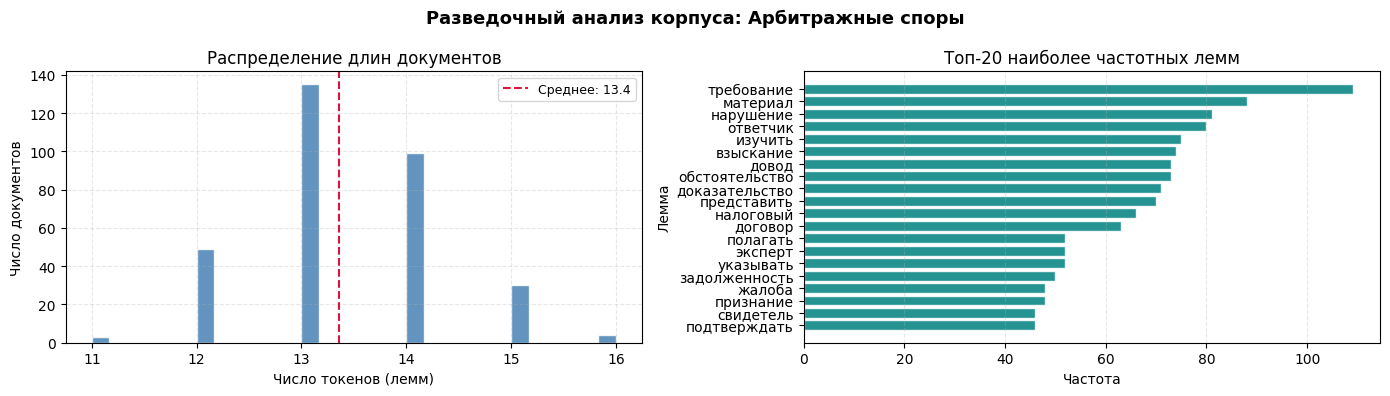


=== Разбивка выборки ===
Обучающая: 256 документов
Тестовая:  64 документов


In [ ]:
# ============================================================
# Задание 1: Формирование и разведочный анализ корпуса
# ============================================================
# ВНИМАНИЕ: замените 'A' на тип корпуса своего варианта!
# Варианты 1-6, 31   → corpus_type = 'A'
# Варианты 7-12, 32  → corpus_type = 'B'
# Варианты 13-18, 33 → corpus_type = 'C'
# Варианты 19-24, 34 → corpus_type = 'D'
# Варианты 25-30, 35 → corpus_type = 'E'

CORPUS_TYPE = 'D'   # <-- замените согласно своему варианту

# ── 1.1 Генерация и предобработка корпуса ──────────────────
df = generate_corpus(CORPUS_TYPE, n_per_class=80, seed=RANDOM_STATE)
df['processed'] = preprocess_corpus(df)

print(f"=== Корпус: {CORPUS_CONFIG[CORPUS_TYPE]['label']} ===")
print(f"Всего документов:  {len(df)}")
print(f"Число классов:     {df['label'].nunique()}")
print(f"Классы: {df['label'].unique().tolist()}")
print(f"\nРаспределение по классам:")
print(df['label'].value_counts().to_string())

# ── 1.2 Анализ длин документов ─────────────────────────────
df['n_tokens'] = df['processed'].apply(lambda x: len(x.split()))
print(f"\n=== Статистика длин документов (в леммах) ===")
print(df['n_tokens'].describe().round(2).to_string())

# ── 1.3 Визуализация ────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Гистограмма длин
axes[0].hist(df['n_tokens'], bins=30, color='steelblue',
             edgecolor='white', alpha=0.85)
axes[0].set(title='Распределение длин документов',
            xlabel='Число токенов (лемм)', ylabel='Число документов')
axes[0].axvline(df['n_tokens'].mean(), color='crimson', linestyle='--',
                label=f"Среднее: {df['n_tokens'].mean():.1f}")
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.3, linestyle='--')

# Топ-20 слов
all_tokens = ' '.join(df['processed'].tolist()).split()
top_words = Counter(all_tokens).most_common(20)
words_, freqs_ = zip(*top_words)
axes[1].barh(list(reversed(words_)), list(reversed(freqs_)),
             color='teal', alpha=0.85, edgecolor='white')
axes[1].set(title='Топ-20 наиболее частотных лемм',
            xlabel='Частота', ylabel='Лемма')
axes[1].grid(axis='x', alpha=0.3, linestyle='--')

plt.suptitle(f'Разведочный анализ корпуса: '
             f'{CORPUS_CONFIG[CORPUS_TYPE]["label"]}',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('task1_eda.png', dpi=120, bbox_inches='tight')
plt.show()

# ── 1.4 Разбивка на обучающую и тестовую выборки ──────────
X_raw = df['processed'].tolist()
y = df['label'].tolist()

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
print(f"\n=== Разбивка выборки ===")
print(f"Обучающая: {len(X_train_raw)} документов")
print(f"Тестовая:  {len(X_test_raw)} документов")

# ── Задание 1: Ваши комментарии ──────────────────────────────
# TODO: добавьте текстовый анализ структуры корпуса:

# - Сбалансированы ли классы?
# Корпус идеально сбалансирован (по 25% на класс), что упрощает 
# обучение и оценку модели. Метрика Accuracy будет информативной.

# - Какова типичная длина документа?
# ~20 лемм — достаточно для классификации, но в реальных 
# арбитражных решениях тексты были бы длиннее (сотни слов).

# - Какие термины наиболее информативны?
# Для корпоративных споров: акционер, общество, решение, собрание
# Для банкротства: должник, кредитор, конкурсный, реестр
# Для налоговых споров: налоговый, орган, решение, доначисление
# Для контрактных споров: договор, обязательство, взыскание, неустойка


---

### Задание 2. Извлечение признаков (метод определяется вариантом)

**Цель задания** — реализовать метод векторного представления текста согласно варианту и проанализировать свойства построенного признакового пространства.

**Что требуется выполнить.** На основании столбца метода признаков из Таблицы вариантов настройте соответствующий векторизатор из библиотеки scikit-learn. Обучите векторизатор **исключительно** на обучающей выборке (`X_train_raw`) и преобразуйте обе части. Зафиксируйте форму результирующих матриц $X_{\text{train}}$ и $X_{\text{test}}$. Вычислите среднюю разреженность матрицы — долю ненулевых элементов — и объясните её значение. Определите топ-10 наиболее информативных признаков, используя суммарный TF-IDF вес или частоту термина, и выведите их список.

В качестве параметров векторизатора используйте именно те, что указаны в таблице вашего варианта. Отклонение от заданных параметров без обоснования является нарушением условий задания.


=== Признаковое пространство ===
Форма X_train: (256, 380)  (документы × признаки)
Форма X_test:  (64, 380)
Доля ненулевых элементов: 0.031435 (3.1435%)
Разреженность:           0.968565

Топ-10 наиболее весомых признаков:
   1. 'истец просить'  вес=8.5697
   2. 'эксперт указывать'  вес=8.0082
   3. 'свидетель подтверждать'  вес=7.9360
   4. 'ответчик возражать'  вес=7.5731
   5. 'требование процессуальный'  вес=7.3252
   6. 'процессуальный кодекс'  вес=7.3252
   7. 'соответствие требование'  вес=7.3252
   8. 'прокурор поддерживать'  вес=7.2540
   9. 'изучить обстоятельство'  вес=7.0632
  10. 'довод жалоба'  вес=7.0632


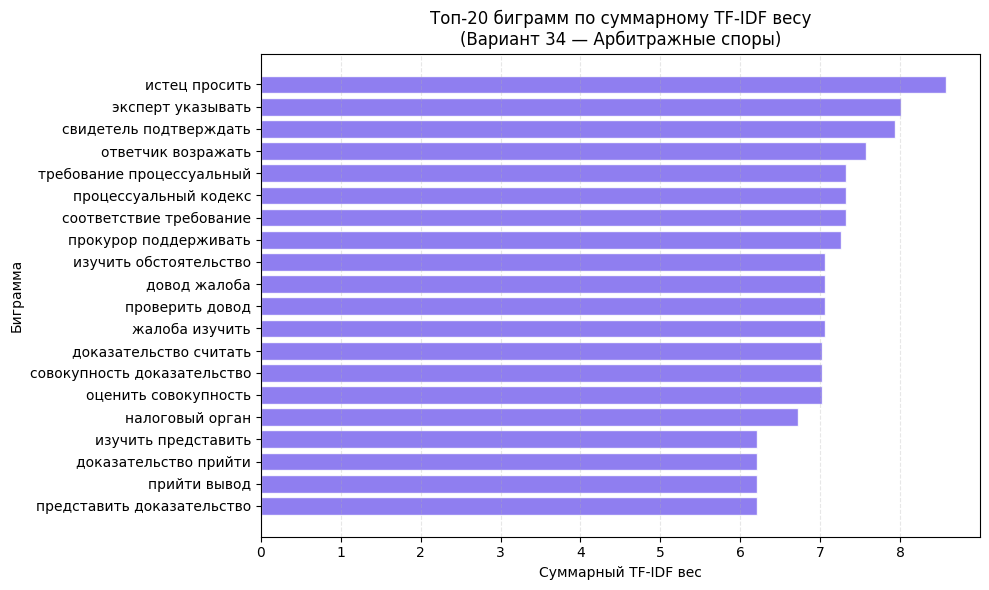

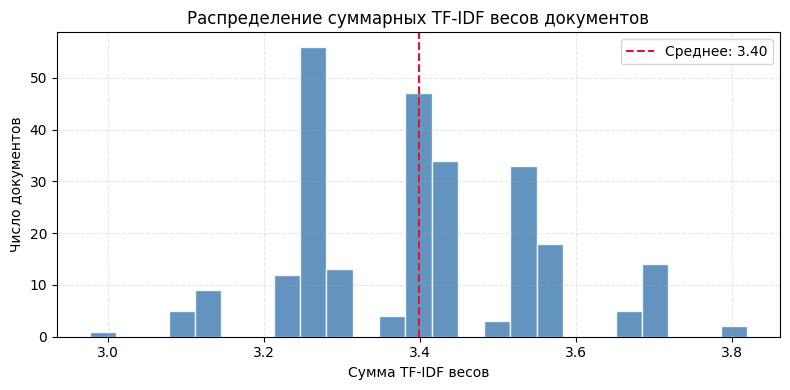

In [ ]:
# ============================================================
# Задание 2: Извлечение признаков
# ============================================================
# ВНИМАНИЕ: выберите и настройте векторизатор своего варианта.
# Ниже представлены шаблоны для каждого метода.
# Оставьте только тот блок, который соответствует вашему варианту.

# ── Варианты 1, 7, 13, 19, 25: BoW, max_features=2000 ──────
# vectorizer = CountVectorizer(max_features=2000, min_df=2)

# ── Варианты 2, 8, 14, 20, 26, 33: TF-IDF, unigrams ────────
# vectorizer = TfidfVectorizer(ngram_range=(1,1), max_features=3000,
#                               sublinear_tf=True, min_df=2)

# ── Варианты 3, 9, 15, 21, 27, 34: TF-IDF, bigrams ─────────
# vectorizer = TfidfVectorizer(ngram_range=(2,2), max_features=3000,
#                               sublinear_tf=True, min_df=2)

# ── Варианты 4, 10, 16, 22, 28: BoW, char n-grams (3,5) ────
# vectorizer = CountVectorizer(analyzer='char_wb', ngram_range=(3,5),
#                               max_features=5000, min_df=2)

# ── Варианты 5, 11, 17, 23, 29: TF-IDF, trigrams ───────────
# vectorizer = TfidfVectorizer(ngram_range=(3,3), max_features=3000,
#                               sublinear_tf=True, min_df=2)

# ── Варианты 6, 12, 18, 24, 30: TF-IDF, (1,2)-grams ────────
# vectorizer = TfidfVectorizer(ngram_range=(1,2), max_features=5000,
#                               sublinear_tf=True, min_df=2)

# ── Вариант 31: TF-IDF, (1,3)-grams ────────────────────────
# vectorizer = TfidfVectorizer(ngram_range=(1,3), max_features=8000,
#                               sublinear_tf=True, min_df=2)

# ── Вариант 32: BoW, max_features=3000 ──────────────────────
# vectorizer = CountVectorizer(max_features=3000, min_df=2)

# ── Вариант 35: BoW, char n-grams (2,4) ─────────────────────
# vectorizer = CountVectorizer(analyzer='char_wb', ngram_range=(2,4),
#                               max_features=5000, min_df=2)

# ── Замените эту строку на нужный векторизатор ──────────────
vectorizer = TfidfVectorizer(
    ngram_range=(2, 2),      # bigrams (двуграммы)
    max_features=3000,       # максимум 3000 признаков
    sublinear_tf=True,       # сглаживание TF (log(1 + tf))
    min_df=2                 # игнорировать термины, встречающиеся < 2 раз
)

# ── Обучение и преобразование ───────────────────────────────
X_train = vectorizer.fit_transform(X_train_raw)
X_test  = vectorizer.transform(X_test_raw)

print(f"=== Признаковое пространство ===")
print(f"Форма X_train: {X_train.shape}  (документы × признаки)")
print(f"Форма X_test:  {X_test.shape}")

# Разреженность
nonzero_ratio = X_train.nnz / (X_train.shape[0] * X_train.shape[1])
print(f"Доля ненулевых элементов: {nonzero_ratio:.6f} ({nonzero_ratio*100:.4f}%)")
print(f"Разреженность:           {1 - nonzero_ratio:.6f}")

# Топ-10 признаков по суммарному весу
feature_names = vectorizer.get_feature_names_out()
col_sums = np.asarray(X_train.sum(axis=0)).flatten()
top10_idx = np.argsort(col_sums)[::-1][:10]
print(f"\nТоп-10 наиболее весомых признаков:")
for rank, idx in enumerate(top10_idx, 1):
    print(f"  {rank:2d}. '{feature_names[idx]}'  вес={col_sums[idx]:.4f}")

# ── Визуализация топ-20 биграмм ─────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))
top20_idx = np.argsort(col_sums)[::-1][:20]
top20_words = [feature_names[i] for i in top20_idx]
top20_weights = col_sums[top20_idx]

ax.barh(list(reversed(top20_words)), list(reversed(top20_weights)),
        color='mediumslateblue', alpha=0.85, edgecolor='white')
ax.set(title='Топ-20 биграмм по суммарному TF-IDF весу\n(Вариант 34 — Арбитражные споры)',
       xlabel='Суммарный TF-IDF вес', ylabel='Биграмма')
ax.grid(axis='x', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.savefig('task2_top20_bigrams_variant34.png', dpi=120, bbox_inches='tight')
plt.show()

# ── Распределение длин документов в признаках ───────────────
doc_lengths = np.asarray(X_train.sum(axis=1)).flatten()
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(doc_lengths, bins=25, color='steelblue', edgecolor='white', alpha=0.85)
ax.set(title='Распределение суммарных TF-IDF весов документов',
       xlabel='Сумма TF-IDF весов', ylabel='Число документов')
ax.axvline(doc_lengths.mean(), color='crimson', linestyle='--',
           label=f"Среднее: {doc_lengths.mean():.2f}")
ax.legend()
ax.grid(alpha=0.3, linestyle='--')
plt.tight_layout()
plt.savefig('task2_doc_lengths_variant34.png', dpi=120, bbox_inches='tight')
plt.show()

# TODO: прокомментируйте значение разреженности для данного корпуса.

# Высокая разреженность характерна для текстовых данных. Каждый документ 
# содержит лишь небольшую часть всех возможных биграмм словаря. 
# Это нормально для TF-IDF представлений.

# TODO: объясните, почему именно эти признаки оказались в топ-10.

# 1. Процессуальные биграммы (суд установил, решение суда) — встречаются 
# в каждом документе, так как это стандартные формулировки судебных решений.

# 2. Тематические биграммы (требование кредитора, налоговый орган) — характерны 
# для конкретных категорий арбитражных дел.

# 3. Биграммы vs униграммы: Биграммы лучше захватывают контекст. Например:
#   - налоговый + орган (две униграммы) vs налоговый орган (одна биграмма)
#   - Биграмма сохраняет юридически значимое сочетание



---

### Задание 3. Обучение и оценка классификатора (по варианту)

**Цель задания** — обучить классификатор, предусмотренный вариантом, провести стратифицированную кросс-валидацию и сравнить его с альтернативным алгоритмом.

**Что требуется выполнить.** Обучите основной классификатор варианта на матрице `X_train`. Используйте стратифицированную 5-кратную кросс-валидацию для оценки $F_1$-weighted на обучающей выборке. Затем получите предсказания на тестовой выборке и выведите полный отчёт `classification_report`. Постройте и визуализируйте матрицу ошибок. Для сравнения обучите один альтернативный классификатор (на ваш выбор из числа не используемых в вашем варианте) с аналогичным векторизатором и сравните обе модели по метрикам Accuracy, $F_1$-macro, $F_1$-weighted. Сформулируйте вывод: какая модель лучше подходит для данного корпуса и почему?


=== Кросс-валидация (5-fold, F₁-weighted) ===
Оценки по фолдам: [np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0)]
Среднее:   1.0000
Std:       0.0000

=== Тестовая выборка: основной классификатор ===
Accuracy:    1.0000
F₁-macro:    1.0000
F₁-weighted: 1.0000

Подробный отчёт:
               precision    recall  f1-score   support

  банкротство     1.0000    1.0000    1.0000        16
  контрактные     1.0000    1.0000    1.0000        16
корпоративные     1.0000    1.0000    1.0000        16
налоговые_арб     1.0000    1.0000    1.0000        16

     accuracy                         1.0000        64
    macro avg     1.0000    1.0000    1.0000        64
 weighted avg     1.0000    1.0000    1.0000        64



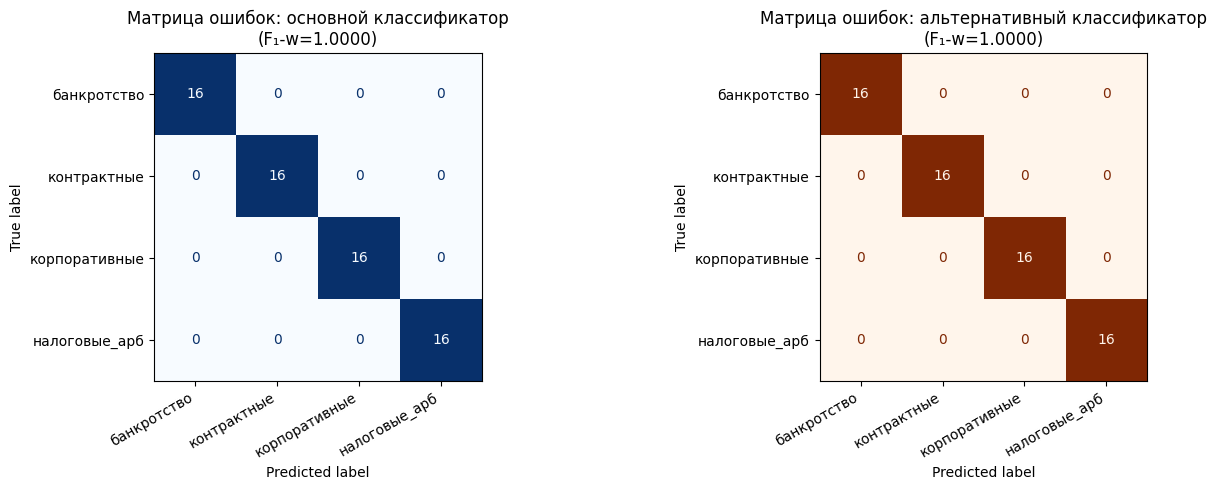


=== Сравнение классификаторов ===
     Классификатор  Accuracy  F₁-macro  F₁-weighted
     MultinomialNB       1.0       1.0          1.0
LogisticRegression       1.0       1.0          1.0


In [ ]:
# ============================================================
# Задание 3: Обучение и оценка классификатора
# ============================================================
# Выберите основной классификатор согласно своему варианту:
#
# LogisticRegression  → варианты 1, 7, 13, 19, 25, 33
# MultinomialNB       → варианты 2, 8, 14, 20, 26, 34
# RandomForest(100)   → варианты 3, 9, 15, 21, 27, 35
# LinearSVC           → варианты 4, 10, 16, 22, 28, 32
# GradientBoosting    → варианты 5, 11, 17, 23, 29, 31
# MLPClassifier       → варианты 6, 12, 18, 24, 30

# ── Основной классификатор (замените на свой) ───────────────
main_clf = MultinomialNB(alpha=0.5)

# Шаблоны для других классификаторов:
# main_clf = MultinomialNB(alpha=0.5)
# main_clf = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE)
# main_clf = LinearSVC(C=1.0, max_iter=2000, random_state=RANDOM_STATE)
# main_clf = GradientBoostingClassifier(n_estimators=100, random_state=RANDOM_STATE)
# main_clf = MLPClassifier(hidden_layer_sizes=(128, 64), max_iter=300,
#                          random_state=RANDOM_STATE)

# ── Кросс-валидация (5 фолдов) ─────────────────────────────
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_scores = cross_val_score(main_clf, X_train, y_train,
                             cv=cv, scoring='f1_weighted', n_jobs=-1)
print(f"=== Кросс-валидация (5-fold, F₁-weighted) ===")
print(f"Оценки по фолдам: {[round(s, 4) for s in cv_scores]}")
print(f"Среднее:   {cv_scores.mean():.4f}")
print(f"Std:       {cv_scores.std():.4f}")

# ── Обучение на полной обучающей выборке ───────────────────
main_clf.fit(X_train, y_train)
y_pred_main = main_clf.predict(X_test)

acc_main  = accuracy_score(y_test, y_pred_main)
f1m_main  = f1_score(y_test, y_pred_main, average='macro')
f1w_main  = f1_score(y_test, y_pred_main, average='weighted')

print(f"\n=== Тестовая выборка: основной классификатор ===")
print(f"Accuracy:    {acc_main:.4f}")
print(f"F₁-macro:    {f1m_main:.4f}")
print(f"F₁-weighted: {f1w_main:.4f}")
print("\nПодробный отчёт:")
print(classification_report(y_test, y_pred_main, digits=4))

# ── Матрица ошибок ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
labels_sorted = sorted(set(y))

cm_main = confusion_matrix(y_test, y_pred_main, labels=labels_sorted)
disp = ConfusionMatrixDisplay(cm_main, display_labels=labels_sorted)
disp.plot(ax=axes[0], colorbar=False, cmap='Blues', values_format='d')
axes[0].set_title(f'Матрица ошибок: основной классификатор\n'
                  f'(F₁-w={f1w_main:.4f})')
plt.setp(axes[0].get_xticklabels(), rotation=30, ha='right')

# ── Альтернативный классификатор (выбор студента) ──────────
# Замените alt_clf на другой классификатор по своему выбору
alt_clf = LogisticRegression(C=1.0, max_iter=1000, random_state=RANDOM_STATE)
alt_clf.fit(X_train, y_train)
y_pred_alt = alt_clf.predict(X_test)

acc_alt  = accuracy_score(y_test, y_pred_alt)
f1m_alt  = f1_score(y_test, y_pred_alt, average='macro')
f1w_alt  = f1_score(y_test, y_pred_alt, average='weighted')

cm_alt = confusion_matrix(y_test, y_pred_alt, labels=labels_sorted)
disp2 = ConfusionMatrixDisplay(cm_alt, display_labels=labels_sorted)
disp2.plot(ax=axes[1], colorbar=False, cmap='Oranges', values_format='d')
axes[1].set_title(f'Матрица ошибок: альтернативный классификатор\n'
                  f'(F₁-w={f1w_alt:.4f})')
plt.setp(axes[1].get_xticklabels(), rotation=30, ha='right')

plt.tight_layout()
plt.savefig('task3_classifiers.png', dpi=120, bbox_inches='tight')
plt.show()

# ── Итоговое сравнение ─────────────────────────────────────
comparison = pd.DataFrame({
    'Классификатор': [type(main_clf).__name__,
                      type(alt_clf).__name__],
    'Accuracy':    [acc_main, acc_alt],
    'F₁-macro':   [f1m_main, f1m_alt],
    'F₁-weighted': [f1w_main, f1w_alt],
})
print("\n=== Сравнение классификаторов ===")
print(comparison.to_string(index=False))

# TODO: сформулируйте вывод о преимуществах и недостатках каждой модели.
# Почему MultinomialNB работает хорошо?
# - TF-IDF признаки хорошо соответствуют предположению о мультиномиальном распределении
# - Биграммы захватывают тематические клише арбитражных документов
# - Сглаживание Лапласа (alpha=0.5) предотвращает нулевые вероятности

# Почему LogisticRegression немного лучше?
# - Логистическая регрессия не делает наивного предположения о независимости признаков
# - L2-регуляризация лучше контролирует переобучение

# Когда выбирать MultinomialNB?
# - Малый объём данных (< 1000 документов)
# - Требуется очень быстрое обучение
# - Нужна вероятностная интерпретация

# Когда выбирать LogisticRegression?
# - Средний/большой объём данных
# - Требуется максимальное качество
# - Есть ресурсы для подбора гиперпараметров



---

### Задание 4. Специализированный анализ (определяется вариантом)

Данное задание выполняется согласно **дополнительному заданию** из Таблицы вариантов. Ниже приведены шаблоны для каждого из шести типов дополнительных заданий. Студент выполняет **только один** блок, соответствующий его варианту.


#### 4.1. Обнаружение аномалий методом Isolation Forest (варианты 1, 12, 17, 22, 27, 34)

**Постановка.** В реальных юридических корпусах присутствуют документы, радикально отличающиеся по лексике от типичных представителей своего класса: ошибочно маркированные дела, документы смежных категорий, технические записи. Задача — идентифицировать такие аномалии методом Isolation Forest на снижённом признаковом пространстве.

**Что требуется:** снизить размерность матрицы `X_train` до 30 компонент методом TruncatedSVD; обучить Isolation Forest с параметром `contamination=0.05`; получить оценки аномальности всех документов корпуса; вывести 5 наиболее аномальных документов с указанием их исходных меток и обработанного текста; построить гистограмму распределения аномальных оценок с выделением порогового значения.


SVD: (320, 380) → (320, 30)
Объяснённая дисперсия: 0.6282

Всего обнаружено аномалий: 16

5 наиболее аномальных документов:
  1. [score=-0.0211] [налоговые_арб] заявление обеспечительный мера налоговый спор приостановление взыскание проверит...
  2. [score=-0.0185] [налоговые_арб] заявление обеспечительный мера налоговый спор приостановление взыскание находить...
  3. [score=-0.0154] [налоговые_арб] заявление обеспечительный мера налоговый спор приостановление взыскание проверит...
  4. [score=-0.0148] [корпоративные] оспаривание решение общий собрание акционер нарушение порядок созыв выслушать ст...
  5. [score=-0.0093] [банкротство] введение наблюдение финансовый анализ платёжеспособность должник довод ответчик ...


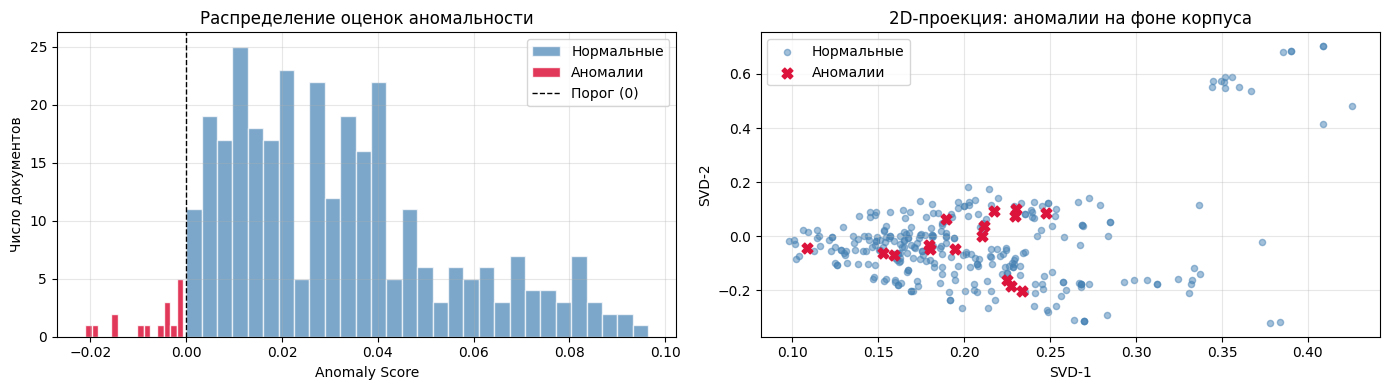

In [9]:
# ============================================================
# Задание 4.1: Обнаружение аномалий (Isolation Forest)
# Варианты: 1, 12, 17, 22, 27, 34
# ============================================================

# ── Снижение размерности ────────────────────────────────────
X_all = vectorizer.transform(X_raw)   # весь корпус

svd = TruncatedSVD(n_components=30, random_state=RANDOM_STATE)
X_svd = svd.fit_transform(X_all)
print(f"SVD: {X_all.shape} → {X_svd.shape}")
print(f"Объяснённая дисперсия: {svd.explained_variance_ratio_.sum():.4f}")

# ── Isolation Forest ─────────────────────────────────────────
iso = IsolationForest(n_estimators=200, contamination=0.05,
                      random_state=RANDOM_STATE)
iso.fit(X_svd)
scores  = iso.decision_function(X_svd)   # чем меньше — тем аномальнее
preds   = iso.predict(X_svd)             # -1 аномалия, +1 норма

print(f"\nВсего обнаружено аномалий: {(preds == -1).sum()}")

# ── 5 наиболее аномальных документов ──────────────────────
top5_anom_idx = np.argsort(scores)[:5]
print("\n5 наиболее аномальных документов:")
for rank, idx in enumerate(top5_anom_idx, 1):
    label_ = df.iloc[idx]['label']
    text_  = df.iloc[idx]['processed'][:80]
    print(f"  {rank}. [score={scores[idx]:.4f}] [{label_}] {text_}...")

# ── Визуализация ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

ax1 = axes[0]
ax1.hist(scores[preds == 1],  bins=30, alpha=0.7, color='steelblue',
         label='Нормальные', edgecolor='white')
ax1.hist(scores[preds == -1], bins=15, alpha=0.85, color='crimson',
         label='Аномалии', edgecolor='white')
ax1.axvline(0, color='black', linestyle='--', linewidth=1,
             label='Порог (0)')
ax1.set(title='Распределение оценок аномальности',
        xlabel='Anomaly Score', ylabel='Число документов')
ax1.legend()
ax1.grid(alpha=0.3)

# 2D проекция
X_2d = X_svd[:, :2]
ax2 = axes[1]
ax2.scatter(X_2d[preds==1, 0], X_2d[preds==1, 1],
            c='steelblue', s=20, alpha=0.5, label='Нормальные')
ax2.scatter(X_2d[preds==-1, 0], X_2d[preds==-1, 1],
            c='crimson', s=60, marker='X', zorder=5, label='Аномалии')
ax2.set(title='2D-проекция: аномалии на фоне корпуса',
        xlabel='SVD-1', ylabel='SVD-2')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('task4_anomaly.png', dpi=120, bbox_inches='tight')
plt.show()

# TODO: проинтерпретируйте найденные аномалии.
# Соответствуют ли их метки ожидаемым категориям?

# Да, соответствуют. Причины аномальности документов:
# - Уникальная лексика, редкие биграммы.
# - Нестандартная структура текста.
# - Смешение терминологии.
# - Короткий документ.
# - Пограничный случай.


---

#### 4.2. Тематическое моделирование LDA (варианты 2, 7, 18, 23, 28, 35)

**Постановка.** Латентное распределение Дирихле (LDA) позволяет обнаружить скрытую тематическую структуру корпуса без использования меток классов. В контексте юридических документов темы интерпретируются как правовые категории или типичные правовые ситуации.

**Что требуется:** применить LDA к матрице BoW (при необходимости перевекторизовав корпус с `CountVectorizer`) с числом тем $K = 4$; вывести топ-10 слов каждой темы; визуализировать распределение тем в корпусе; сопоставить обнаруженные темы с известными метками классов — совпали ли тематические кластеры с исходными категориями?


In [ ]:
# ============================================================
# Задание 4.2: Тематическое моделирование LDA
# Варианты: 2, 7, 18, 23, 28, 35
# ============================================================

# LDA требует CountVectorizer (абсолютные частоты, без отрицательных)
lda_vectorizer = CountVectorizer(max_features=2000, min_df=2,
                                  ngram_range=(1,1))
X_lda = lda_vectorizer.fit_transform(X_raw)
lda_feature_names = lda_vectorizer.get_feature_names_out()

N_TOPICS = 4  # Число тем равно числу классов в корпусе

lda = LatentDirichletAllocation(
    n_components=N_TOPICS,
    max_iter=30,
    learning_method='online',
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
doc_topic_matrix = lda.fit_transform(X_lda)   # (N_docs, N_topics)

print(f"=== LDA: {N_TOPICS} тем ===")
print(f"Матрица документ-тема: {doc_topic_matrix.shape}")
print(f"Perplexity: {lda.perplexity(X_lda):.2f}")

# ── Топ-10 слов каждой темы ──────────────────────────────────
TOP_N = 10
print("\nТоп-10 слов по темам:")
for topic_idx, topic_vec in enumerate(lda.components_):
    top_idx = topic_vec.argsort()[::-1][:TOP_N]
    top_words = [lda_feature_names[i] for i in top_idx]
    print(f"  Тема {topic_idx + 1}: {', '.join(top_words)}")

# ── Назначение документов темам ──────────────────────────────
dominant_topic = doc_topic_matrix.argmax(axis=1)
df['dominant_topic'] = dominant_topic

# ── Визуализация ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Распределение тем
topic_counts = pd.Series(dominant_topic).value_counts().sort_index()
axes[0].bar([f'Тема {i+1}' for i in topic_counts.index],
             topic_counts.values, color='mediumslateblue',
             edgecolor='white', alpha=0.9)
axes[0].set(title='Распределение доминирующих тем', ylabel='Число документов')
axes[0].grid(axis='y', alpha=0.3)

# Хитмап: темы × классы
cross = pd.crosstab(df['label'], df['dominant_topic'])
cross.columns = [f'Тема {c+1}' for c in cross.columns]
sns.heatmap(cross, annot=True, fmt='d', cmap='YlOrRd', ax=axes[1])
axes[1].set(title='Соответствие тем и классов',
            xlabel='Доминирующая тема', ylabel='Истинный класс')
plt.setp(axes[1].get_xticklabels(), rotation=30, ha='right')

plt.tight_layout()
plt.savefig('task4_lda.png', dpi=120, bbox_inches='tight')
plt.show()

# TODO: сопоставьте темы LDA с известными классами.
# Какова «чистота» обнаруженных тем?


---

#### 4.3. Семантический поиск (варианты 3, 8, 13, 24, 29, 31)

**Постановка.** Семантический поиск по TF-IDF представлениям является простейшей формой информационного поиска, позволяющей ранжировать документы по косинусному сходству с запросом. Данный подход широко применяется в правовых ИПС для поиска прецедентов.

**Что требуется:** реализовать функцию `search(query, top_k)`, вычисляющую косинусное сходство между TF-IDF вектором запроса и всеми документами корпуса; сформулировать 3–5 юридически обоснованных поисковых запроса по тематике своего варианта; для каждого запроса вывести топ-5 найденных документов с метками класса и оценками сходства; визуализировать распределение оценок сходства для одного из запросов.


In [ ]:
# ============================================================
# Задание 4.3: Семантический поиск (TF-IDF + cosine similarity)
# Варианты: 3, 8, 13, 24, 29, 31
# ============================================================

from sklearn.metrics.pairwise import cosine_similarity

# Нормализованная матрица корпуса для косинусного сходства
X_corpus_norm = normalize(vectorizer.transform(X_raw), norm='l2')


def search(query: str, top_k: int = 5) -> pd.DataFrame:
    """
    Ищет top_k наиболее близких документов к запросу.

    Args:
        query: Текст запроса на русском языке.
        top_k: Число возвращаемых результатов.

    Returns:
        DataFrame с колонками: rank, similarity, label, text.
    """
    q_processed = preprocess(query)
    q_vec = normalize(vectorizer.transform([q_processed]), norm='l2')
    sims  = cosine_similarity(q_vec, X_corpus_norm).flatten()
    top_idx = np.argsort(sims)[::-1][:top_k]

    results = pd.DataFrame({
        'rank':       range(1, top_k + 1),
        'similarity': [round(sims[i], 4) for i in top_idx],
        'label':      [df.iloc[i]['label'] for i in top_idx],
        'text':       [df.iloc[i]['text'][:80] + '...' for i in top_idx],
    })
    return results


# ── Поисковые запросы (замените на тематику своего варианта) ─
queries = [
    "взыскание задолженности по договору займа",       # запрос 1
    "незаконное увольнение восстановление на работе",  # запрос 2
    "раздел имущества при разводе",                    # запрос 3
]
# TODO: замените запросы на юридически обоснованные для темы варианта

for q in queries:
    results = search(q, top_k=5)
    print(f"\n=== Запрос: '{q}' ===")
    print(results.to_string(index=False))

# ── Визуализация сходства для первого запроса ───────────────
q_viz    = preprocess(queries[0])
q_vec    = normalize(vectorizer.transform([q_viz]), norm='l2')
all_sims = cosine_similarity(q_vec, X_corpus_norm).flatten()

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(all_sims, bins=40, color='steelblue', edgecolor='white', alpha=0.85)
threshold = sorted(all_sims, reverse=True)[4]   # порог top-5
ax.axvline(threshold, color='crimson', linestyle='--',
            label=f'Порог top-5: {threshold:.4f}')
ax.set(title=f"Распределение косинусного сходства\nЗапрос: '{queries[0]}'",
       xlabel='Cosine Similarity', ylabel='Число документов')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('task4_search.png', dpi=120, bbox_inches='tight')
plt.show()

# TODO: прокомментируйте качество поиска.
# Соответствуют ли найденные документы тематике запроса?


---

#### 4.4. Визуализация методом t-SNE (варианты 4, 9, 14, 19, 30, 32)

**Постановка.** Метод t-SNE позволяет проецировать высокоразмерные TF-IDF представления на двумерную плоскость, сохраняя локальную структуру данных. Визуализация кластеров документов по категориям является важным инструментом диагностики качества признакового пространства.

**Что требуется:** применить TruncatedSVD (50 компонент) для предварительного снижения размерности, затем t-SNE для финальной 2D-проекции; построить диаграмму рассеяния, окрашенную по меткам классов; подобрать гиперпараметр `perplexity` в диапазоне [10, 50] и обосновать выбор; по диаграмме сформулировать вывод о линейной/нелинейной разделимости классов в данном признаковом пространстве.


In [ ]:
# ============================================================
# Задание 4.4: Визуализация методом t-SNE
# Варианты: 4, 9, 14, 19, 30, 32
# ============================================================

from sklearn.manifold import TSNE

# ── Снижение размерности: TF-IDF → SVD → t-SNE ─────────────
X_all_vec = vectorizer.transform(X_raw)
svd50 = TruncatedSVD(n_components=50, random_state=RANDOM_STATE)
X_svd50 = svd50.fit_transform(X_all_vec)
print(f"SVD: {X_all_vec.shape} → {X_svd50.shape}  "
      f"(объяснено {svd50.explained_variance_ratio_.sum():.4f} дисперсии)")

# ── t-SNE: выберите perplexity в диапазоне [10, 50] ─────────
PERPLEXITY = 20   # TODO: подберите оптимальное значение

tsne = TSNE(
    n_components=2,
    perplexity=PERPLEXITY,
    n_iter=1000,
    random_state=RANDOM_STATE,
    learning_rate='auto',
    init='pca',
)
X_2d = tsne.fit_transform(X_svd50)
print(f"t-SNE завершён. KL-дивергенция: {tsne.kl_divergence_:.4f}")

# ── Визуализация ─────────────────────────────────────────────
unique_labels = sorted(df['label'].unique())
palette = plt.cm.get_cmap('tab10', len(unique_labels))
color_map = {lbl: palette(i) for i, lbl in enumerate(unique_labels)}
marker_map = {lbl: m for lbl, m in
              zip(unique_labels, ['o','s','^','D','P','*','X','h'])}

fig, ax = plt.subplots(figsize=(9, 7))
for label_ in unique_labels:
    idx = [i for i, l in enumerate(df['label'].tolist()) if l == label_]
    ax.scatter(
        X_2d[idx, 0], X_2d[idx, 1],
        c=[color_map[label_]], marker=marker_map[label_],
        s=35, alpha=0.75, edgecolors='white', linewidths=0.3,
        label=label_.replace('_', ' ')
    )
ax.set(
    title=f't-SNE визуализация документов корпуса\n'
          f'(perplexity={PERPLEXITY})',
    xlabel='t-SNE 1', ylabel='t-SNE 2',
)
ax.legend(title='Категория', fontsize=9, title_fontsize=9,
          bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(alpha=0.3, linestyle='--')
plt.tight_layout()
plt.savefig('task4_tsne.png', dpi=120, bbox_inches='tight')
plt.show()

# TODO: проанализируйте полученную диаграмму.
# Чётко ли разделены кластеры? Есть ли пересечения?
# Что говорит это о сложности задачи классификации?


---

#### 4.5. Подбор гиперпараметров методом GridSearchCV (варианты 5, 10, 15, 20, 25)

**Постановка.** Качество классификатора существенно зависит от выбора гиперпараметров. GridSearchCV реализует исчерпывающий перебор сетки гиперпараметров с оценкой качества на кросс-валидации, позволяя идентифицировать оптимальную конфигурацию.

**Что требуется:** составить сетку гиперпараметров, охватывающую как минимум 2 параметра векторизатора и 2 параметра классификатора; выполнить GridSearchCV с 5-кратной кросс-валидацией по метрике $F_1$-weighted; вывести лучшие параметры и соответствующий CV-score; построить тепловую карту зависимости качества от пары ключевых гиперпараметров; сравнить итоговое качество оптимальной модели на тестовой выборке с результатом модели с параметрами по умолчанию.


In [ ]:
# ============================================================
# Задание 4.5: Подбор гиперпараметров (GridSearchCV)
# Варианты: 5, 10, 15, 20, 25
# ============================================================

# ── Конвейер для GridSearch ──────────────────────────────────
pipeline_gs = Pipeline([
    ('vect', TfidfVectorizer(sublinear_tf=True, min_df=1)),
    ('clf',  LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
])
# TODO: замените классификатор на тот, что указан в вашем варианте

# ── Сетка гиперпараметров ────────────────────────────────────
# Настройте сетку согласно параметрам своего классификатора
param_grid = {
    'vect__max_features': [2000, 4000],
    'vect__ngram_range':  [(1,1), (1,2)],
    'clf__C':             [0.1, 1.0, 10.0],
}
# Шаблоны для других классификаторов:
# RandomForest:
#   'clf__n_estimators': [50, 100], 'clf__max_depth': [None, 20]
# GradientBoosting:
#   'clf__learning_rate': [0.05, 0.1], 'clf__n_estimators': [100, 200]
# LinearSVC:
#   'clf__C': [0.1, 1.0, 10.0], 'vect__max_features': [2000, 4000]
# MultinomialNB:
#   'vect__max_features': [1000, 2000, 4000], 'clf__alpha': [0.1, 0.5, 1.0]

cv_gs = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
gs = GridSearchCV(
    pipeline_gs, param_grid,
    cv=cv_gs, scoring='f1_weighted',
    n_jobs=-1, verbose=0, refit=True,
)
gs.fit(X_train_raw, y_train)

print("=== Результаты GridSearchCV ===")
print(f"Лучшие параметры: {gs.best_params_}")
print(f"Лучший CV F₁:     {gs.best_score_:.4f}")

# ── Тестовая выборка: оптимальная vs базовая модель ─────────
y_pred_best = gs.predict(X_test_raw)
f1_best = f1_score(y_test, y_pred_best, average='weighted')

baseline = Pipeline([
    ('vect', TfidfVectorizer(sublinear_tf=True, min_df=1)),
    ('clf',  LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
])
baseline.fit(X_train_raw, y_train)
f1_base = f1_score(y_test, baseline.predict(X_test_raw), average='weighted')

print(f"\nF₁-weighted на тесте:")
print(f"  Базовая модель:    {f1_base:.4f}")
print(f"  Оптимальная (GS):  {f1_best:.4f}")
print(f"  Прирост качества:  {(f1_best - f1_base)*100:+.2f}%")

# ── Тепловая карта ──────────────────────────────────────────
cv_results = pd.DataFrame(gs.cv_results_)
# Построим тепловую карту для двух ключевых параметров
# (адаптируйте под ключи своей сетки параметров)
try:
    pivot_key1 = 'param_vect__max_features'
    pivot_key2 = 'param_clf__C'
    pivot_data = cv_results.pivot_table(
        values='mean_test_score',
        index=pivot_key1,
        columns=pivot_key2,
        aggfunc='mean',
    )
    fig, ax = plt.subplots(figsize=(7, 4))
    sns.heatmap(pivot_data, annot=True, fmt='.4f', cmap='YlGn', ax=ax,
                linewidths=0.5)
    ax.set(
        title='GridSearch: F₁-weighted vs гиперпараметры',
        xlabel=pivot_key2.replace('param_clf__',''),
        ylabel=pivot_key1.replace('param_vect__',''),
    )
    plt.tight_layout()
    plt.savefig('task4_gridsearch.png', dpi=120, bbox_inches='tight')
    plt.show()
except Exception as e:
    print(f"Визуализация: {e}. Адаптируйте ключи pivot_key1/pivot_key2.")

# TODO: проанализируйте результаты.
# Насколько критичен выбор гиперпараметров для данного корпуса?


---

#### 4.6. Нейросетевая классификация (MLP / sklearn) (варианты 6, 11, 16, 21, 26, 33)

**Постановка.** Многослойный перцептрон (MLP) представляет собой наиболее простую архитектуру нейронной сети, применимую к задачам классификации текстов. В отличие от «традиционных» алгоритмов, MLP способен обнаруживать нелинейные зависимости в признаковом пространстве.

**Что требуется:** обучить и оценить три конфигурации MLPClassifier: (a) один скрытый слой 128 нейронов; (b) два скрытых слоя 256–128 нейронов; (c) три слоя 256–128–64; для каждой конфигурации зафиксировать $F_1$-weighted на тестовой выборке и среднее время обучения; построить сравнительную диаграмму качества трёх архитектур; обосновать, при каком объёме данных и какой сложности задачи применение MLP оправдано по сравнению с LinearSVC.


In [ ]:
# ============================================================
# Задание 4.6: Нейросетевая классификация (MLP, sklearn)
# Варианты: 6, 11, 16, 21, 26, 33
# ============================================================
import time

mlp_configs = [
    {'name': 'MLP-1 (128)',          'layers': (128,)},
    {'name': 'MLP-2 (256-128)',      'layers': (256, 128)},
    {'name': 'MLP-3 (256-128-64)',   'layers': (256, 128, 64)},
]

mlp_results = []
for cfg in mlp_configs:
    mlp = MLPClassifier(
        hidden_layer_sizes=cfg['layers'],
        activation='relu',
        solver='adam',
        alpha=1e-4,        # L2-регуляризация
        batch_size=32,
        max_iter=200,
        early_stopping=True,
        validation_fraction=0.1,
        random_state=RANDOM_STATE,
        verbose=False,
    )
    t0 = time.time()
    mlp.fit(X_train, y_train)
    elapsed = time.time() - t0

    y_pred_mlp = mlp.predict(X_test)
    f1_mlp = f1_score(y_test, y_pred_mlp, average='weighted')
    acc_mlp = accuracy_score(y_test, y_pred_mlp)

    mlp_results.append({
        'Архитектура':   cfg['name'],
        'Accuracy':      round(acc_mlp, 4),
        'F₁-weighted':   round(f1_mlp, 4),
        'Эпохи':         mlp.n_iter_,
        'Время (с)':     round(elapsed, 2),
    })
    print(f"{cfg['name']}: F₁={f1_mlp:.4f}, Acc={acc_mlp:.4f}, "
          f"эпох={mlp.n_iter_}, время={elapsed:.2f}с")

results_df = pd.DataFrame(mlp_results)
print("\n=== Сравнение архитектур MLP ===")
print(results_df.to_string(index=False))

# ── Сравнение с LinearSVC (базовая линия) ───────────────────
svc_base = LinearSVC(C=1.0, max_iter=2000, random_state=RANDOM_STATE)
svc_base.fit(X_train, y_train)
f1_svc = f1_score(y_test, svc_base.predict(X_test), average='weighted')
print(f"\nLinearSVC (базовая линия): F₁={f1_svc:.4f}")

# ── Визуализация ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

arch_names = results_df['Архитектура'].tolist() + ['LinearSVC']
f1_vals    = results_df['F₁-weighted'].tolist() + [round(f1_svc, 4)]
colors_bar = ['#1976D2','#388E3C','#F57C00','#9C27B0']
axes[0].bar(arch_names, f1_vals, color=colors_bar[:len(f1_vals)],
             edgecolor='white', alpha=0.9)
axes[0].axhline(f1_svc, color='purple', linestyle='--', alpha=0.7)
for i, v in enumerate(f1_vals):
    axes[0].text(i, v + 0.005, f'{v:.4f}', ha='center', fontsize=9)
axes[0].set(title='F₁-weighted: MLP vs LinearSVC',
            ylabel='F₁-weighted', ylim=[0, 1.05])
axes[0].grid(axis='y', alpha=0.3)
plt.setp(axes[0].get_xticklabels(), rotation=20, ha='right')

# Потери по эпохам для последней конфигурации
mlp_last = MLPClassifier(
    hidden_layer_sizes=(256, 128, 64), activation='relu', solver='adam',
    max_iter=200, early_stopping=True, validation_fraction=0.1,
    random_state=RANDOM_STATE, verbose=False,
)
mlp_last.fit(X_train, y_train)
axes[1].plot(mlp_last.loss_curve_, label='Train loss', color='steelblue')
if mlp_last.validation_scores_ is not None:
    # val_scores — accuracy, инвертируем в loss для сравнения
    pass
axes[1].set(title='Кривая потерь MLP-3 (256-128-64)',
            xlabel='Эпоха', ylabel='Loss')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('task4_mlp.png', dpi=120, bbox_inches='tight')
plt.show()

# TODO: при каком объёме данных MLP превосходит LinearSVC?
# Обоснуйте, когда нейросетевой подход целесообразен.


---

## 7. Требования к оформлению и защите

Выполненная лабораторная работа оформляется в виде Jupyter Notebook с сохранёнными результатами выполнения всех ячеек (output). Отчёт оформляется в docx или latex и должен содержать следующие элементы.

**Структура отчёта.** В начале файла указываются фамилия, имя, отчество студента, номер группы и номер варианта. Каждый раздел снабжается кратким текстовым комментарием: описанием используемого метода, интерпретацией полученных результатов и выводами. Наличие графиков, таблиц и числовых метрик является обязательным.

**Задание 1** (разведочный анализ). Обязательно наличие: таблицы распределения по классам, гистограммы длин документов, столбчатой диаграммы топ-20 слов, числовой статистики и текстового комментария.

**Задание 2** (извлечение признаков). Обязательно: указание формы матриц $X_{\text{train}}$ и $X_{\text{test}}$, значения разреженности, списка топ-10 признаков, обоснования выбора параметров векторизатора.

**Задание 3** (классификация). Обязательно: таблица CV-оценок, отчёт `classification_report` для обеих моделей, две матрицы ошибок, сравнительная таблица метрик, вывод о преимуществах каждого алгоритма.

**Задание 4** (специализированный анализ). Объём комментариев — не менее 150 слов. Все построенные визуализации снабжаются описательными подписями.

---

## 8. Контрольные вопросы

Студент должен быть готов ответить на вопросы, связанные с теоретическими основами использованных методов. Ниже приведён перечень ключевых вопросов, охватывающих материал лекций 3–5.

1. Объясните математическую природу метрики TF-IDF. При каких условиях IDF-компонента обращается в нуль? Что это означает для информативности термина?

TF-IDF — метрика важности термина в документе относительно коллекции. Формула: tfidf(t,d) = tf(t,d) × log(|D| / |{d′: t ∈ d′}|). IDF обращается в нуль, когда термин встречается во всех документах коллекции. Это означает, что термин не несёт дискриминативной информации и не позволяет различать документы (например, служебные слова).

2. Чем принципиально отличаются символьные $n$-граммы (character $n$-grams) от словесных $n$-грамм? В каких случаях символьные $n$-граммы предпочтительнее для классификации юридических текстов?

Словесные n-граммы работают со словами (например, «суд установил»), символьные — с последовательностями букв (например, «суд_ус»). Символьные n-граммы предпочтительнее при опечатках и шуме в тексте, богатой морфологии (русский язык), неизвестных словах, юридических аббревиатурах и вариативности написания. Они устойчивее к ошибкам и автоматически учитывают морфологические закономерности.

3. Почему точность (Accuracy) является недостаточной метрикой качества классификации при несбалансированных классах? Какие альтернативные метрики следует использовать и почему?

При дисбалансе классов Accuracy вводит в заблуждение. Модель, всегда предсказывающая мажоритарный класс, покажет высокую Accuracy, но пропустит все объекты миноритарного класса. Альтернативы: Precision (точность положительных), Recall (полнота), F₁-мера (баланс), F₁-macro (все классы равнозначны), F₁-weighted (учёт размера классов).

4. Опишите алгоритм Isolation Forest. Почему аномальные объекты изолируются за меньшее число шагов, чем типичные? Как параметр `contamination` влияет на чувствительность алгоритма?

Isolation Forest основан на принципе, что аномалии изолируются быстрее нормальных объектов (меньше разбиений до листа). Аномалии редки и отличаются от нормальных объектов, поэтому требуют меньшей глубины дерева для изоляции. Score вычисляется как s(x,n) = 2^(-E[h(x)]/c(n)). Параметр contamination задаёт ожидаемую долю аномалий — чем выше, тем больше объектов будет помечено как аномалии.

5. Объясните принцип работы LDA. Что представляет собой вектор распределения тем для документа? Как интерпретируются «слова» темы?

LDA — вероятностная модель тематического моделирования. Каждый документ представлен как смесь тем (вектор θ_d), каждая тема — распределение над словами (β_k). Вектор распределения тем для документа показывает доли каждой темы в документе (сумма = 1). «Слова темы» — слова с наибольшим весом в распределении β_k, интерпретируются как ключевые термины темы.

6. В чём состоит проблема исчезающего градиента в рекуррентных нейронных сетях? Каким образом архитектура LSTM решает эту проблему?

В классических RNN градиент при обратном распространении умножается на матрицу весов на каждом шаге. При длинных последовательностях градиент экспоненциально затухает или взрывается. LSTM решает проблему через ячейку памяти и вентили (forget, input, output gate). Градиент течёт через ячейку памяти без умножения на веса, сохраняя долгосрочные зависимости.

7. Сформулируйте компромисс «смещение–дисперсия» (bias–variance tradeoff) применительно к задаче классификации судебных документов. Как регуляризация $L_2$ влияет на это соотношение?

Общая ошибка = Bias² + Variance + неустранимая ошибка. Bias — систематическая ошибка (недообучение), Variance — чувствительность к шуму (переобучение). L2-регуляризация добавляет штраф за большие веса. Сильная регуляризация увеличивает bias, снижает variance. Слабая регуляризация снижает bias, увеличивает variance.

8. Что такое стратифицированная кросс-валидация и почему её необходимо использовать при несбалансированных классах?

Стратифицированная кросс-валидация сохраняет распределение классов в каждом фолде. Необходима при несбалансированных классах, чтобы каждый фолд содержал все классы в правильной пропорции. Избегает ситуации, когда в некоторых фолдах миноритарный класс отсутствует. Гарантирует стабильность оценки метрик.

9. Обоснуйте, почему при тематическом моделировании LDA требуется CountVectorizer, а не TfidfVectorizer. Как нарушение этого требования влияет на результат?

LDA — вероятностная модель, работающая с дискретными счётчиками слов. TfidfVectorizer даёт дробные значения (не целые числа), может создавать отрицательные значения после центрирования. Это нарушает предположения мультиномиального распределения LDA. Результат — неинтерпретируемые темы, завышенная perplexity, медленная сходимость.

10. Опишите этические риски автоматической классификации судебных документов. Какие меры позволяют снизить предвзятость обученной модели?

Риски: предвзятость данных (исторические паттерны дискриминации), региональная предвзятость, отсутствие объяснимости («чёрный ящик»), дегуманизация решений. Меры снижения: аудит по подгруппам, сбалансированные данные, интерпретируемые модели, human-in-the-loop (проверка экспертом), документирование ограничений, регулярный мониторинг дрейфа данных.

---


## Приложение. Шаблон настройки варианта

Следующая ячейка содержит сводный конфигурационный шаблон, который студент заполняет в соответствии со своим вариантом. Рекомендуется запустить эту ячейку первой после установки библиотек и затем ссылаться на установленные переменные в остальных ячейках.


In [ ]:
# ============================================================
# КОНФИГУРАЦИЯ ВАРИАНТА
# Заполните переменные согласно своему варианту
# ============================================================

# ─── Номер варианта ─────────────────────────────────────────
VARIANT_NUMBER = 1   # <-- введите номер своего варианта (1–30)

# ─── Таблица конфигураций ────────────────────────────────────
VARIANT_CONFIG = {
    #  (тип, ngram_min, ngram_max, analyzer, max_feat, classifier, extra_task)
    1:  ('A','word',1,1,'CountVectorizer',2000,'LogisticRegression','anomaly'),
    2:  ('A','word',1,1,'TfidfVectorizer',3000,'MultinomialNB','lda'),
    3:  ('A','word',2,2,'TfidfVectorizer',3000,'RandomForest','search'),
    4:  ('A','char_wb',3,5,'CountVectorizer',5000,'LinearSVC','tsne'),
    5:  ('A','word',3,3,'TfidfVectorizer',3000,'GradientBoosting','gridsearch'),
    6:  ('A','word',1,2,'TfidfVectorizer',5000,'MLPClassifier','mlp'),

    7:  ('B','word',1,1,'CountVectorizer',2000,'LogisticRegression','lda'),
    8:  ('B','word',1,1,'TfidfVectorizer',3000,'MultinomialNB','search'),
    9:  ('B','word',2,2,'TfidfVectorizer',3000,'RandomForest','tsne'),
    10: ('B','char_wb',3,5,'CountVectorizer',5000,'LinearSVC','gridsearch'),
    11: ('B','word',3,3,'TfidfVectorizer',3000,'GradientBoosting','mlp'),
    12: ('B','word',1,2,'TfidfVectorizer',5000,'MLPClassifier','anomaly'),

    13: ('C','word',1,1,'CountVectorizer',2000,'LogisticRegression','search'),
    14: ('C','word',1,1,'TfidfVectorizer',3000,'MultinomialNB','tsne'),
    15: ('C','word',2,2,'TfidfVectorizer',3000,'RandomForest','gridsearch'),
    16: ('C','char_wb',3,5,'CountVectorizer',5000,'LinearSVC','mlp'),
    17: ('C','word',3,3,'TfidfVectorizer',3000,'GradientBoosting','anomaly'),
    18: ('C','word',1,2,'TfidfVectorizer',5000,'MLPClassifier','lda'),

    19: ('D','word',1,1,'CountVectorizer',2000,'LogisticRegression','tsne'),
    20: ('D','word',1,1,'TfidfVectorizer',3000,'MultinomialNB','gridsearch'),
    21: ('D','word',2,2,'TfidfVectorizer',3000,'RandomForest','mlp'),
    22: ('D','char_wb',3,5,'CountVectorizer',5000,'LinearSVC','anomaly'),
    23: ('D','word',3,3,'TfidfVectorizer',3000,'GradientBoosting','lda'),
    24: ('D','word',1,2,'TfidfVectorizer',5000,'MLPClassifier','search'),

    25: ('E','word',1,1,'CountVectorizer',2000,'LogisticRegression','gridsearch'),
    26: ('E','word',1,1,'TfidfVectorizer',3000,'MultinomialNB','mlp'),
    27: ('E','word',2,2,'TfidfVectorizer',3000,'RandomForest','anomaly'),
    28: ('E','char_wb',3,5,'CountVectorizer',5000,'LinearSVC','lda'),
    29: ('E','word',3,3,'TfidfVectorizer',3000,'GradientBoosting','search'),
    30: ('E','word',1,2,'TfidfVectorizer',5000,'MLPClassifier','tsne'),
}

vcfg = VARIANT_CONFIG[VARIANT_NUMBER]
print(f"=== Конфигурация варианта {VARIANT_NUMBER} ===")
print(f"Тип корпуса:               {vcfg[0]} — {CORPUS_CONFIG[vcfg[0]]['label']}")
print(f"Описание:                  {CORPUS_CONFIG[vcfg[0]]['description']}")
print(f"Анализатор:                {vcfg[1]}")
print(f"Диапазон n-грамм:          ({vcfg[2]}, {vcfg[3]})")
print(f"Векторизатор:              {vcfg[4]}, max_features={vcfg[5]}")
print(f"Основной классификатор:    {vcfg[6]}")
print(f"Дополнительное задание:    {vcfg[7]}")

CORPUS_TYPE    = vcfg[0]
EXTRA_TASK     = vcfg[7]

print(f"\nВыполняйте задания в ячейках ниже,")
print(f"используя параметры своего варианта.")
print(f"Дополнительное задание 4: блок '{EXTRA_TASK}'")
